# 🦴 EXP-009: Pose Kinematic Threshold Tuning & Benchmark on UR Fall Dataset

Notebook ini menjalankan **Grid Search & Evaluasi Kuantitatif** untuk paradigma **YOLO11-Pose (Keypoint Skeleton)** pada dataset benchmark UR Fall.

### 🎯 Tujuan Eksperimen:
1. Mengekstrak 17 koordinat sendi tubuh pada gambar dataset UR Fall.
2. Memvisualisasikan distribusi sudut kemiringan tulang belakang (*spine tilt angle* $\theta$) pada kelas `normal`, `transitional`, dan `lying_on_ground`.
3. Menemukan kombinasi threshold sudut optimal melalui **Grid Search** pada Validation Set.
4. Menguji secara independen pada **Test Set (320 gambar)** dan membandingkan performanya secara langsung (*head-to-head*) dengan **EXP-006 Champion**.

### 1. Setup Environment & Import Libraries

In [1]:
import os
import math
import time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
from ultralytics import YOLO

print(f"PyTorch Version : {torch.__version__}")
print(f"CUDA Available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device Name     : {torch.cuda.get_device_name(0)}")

CLASS_NAMES = {0: "normal", 1: "transitional", 2: "lying_on_ground"}

PyTorch Version : 2.6.0+cu124
CUDA Available  : True
Device Name     : NVIDIA GeForce RTX 2050


### 2. Deteksi Lokasi Dataset (Bisa di Lokal maupun di Kaggle)

In [2]:
# Mendukung path lokal maupun Kaggle secara otomatis
candidate_paths = [
    Path("../data/processed"),
    Path("ml/data/processed"),
    Path("/kaggle/input/datasets/rajarahmanaziiz/fall-detection-dataset"),
    Path("/kaggle/input/fall-detection-dataset"),
]

dataset_dir = None
for p in candidate_paths:
    if (p / "images").exists():
        dataset_dir = p.resolve()
        break
    if (p / "data.yaml").exists():
        dataset_dir = p.resolve()
        break

if not dataset_dir:
    # Fallback pencarian rekursif
    for root in [Path("."), Path("/kaggle/input")]:
        sub_imgs = list(root.glob("**/images/val"))
        if sub_imgs:
            dataset_dir = sub_imgs[0].parent.parent.resolve()
            break

if dataset_dir:
    print(f"✅ Dataset berhasil ditemukan di: {dataset_dir}")
    val_img_dir = dataset_dir / "images" / "val"
    val_lbl_dir = dataset_dir / "labels" / "val"
    test_img_dir = dataset_dir / "images" / "test"
    test_lbl_dir = dataset_dir / "labels" / "test"
    print(f"   Val images  : {len(list(val_img_dir.glob('*.*')))} file")
    print(f"   Test images : {len(list(test_img_dir.glob('*.*')))} file")
else:
    raise FileNotFoundError("❌ Folder dataset tidak ditemukan!")

✅ Dataset berhasil ditemukan di: C:\Project_2026\Falling Detection\ml\data\processed
   Val images  : 254 file
   Test images : 320 file


### 3. Definisi Fungsi Ekstraksi Sudut Kinematika Tulang Belakang

In [3]:
def calculate_spine_angle(kpts: np.ndarray) -> float:
    """Menghitung sudut tulang belakang terhadap bidang horizontal (0° = tidur, 90° = tegak)."""
    l_sh, r_sh = kpts[5][:2], kpts[6][:2]    # Bahu kiri & kanan
    l_hip, r_hip = kpts[11][:2], kpts[12][:2] # Pinggul kiri & kanan

    mid_sh = ((l_sh[0] + r_sh[0]) / 2, (l_sh[1] + r_sh[1]) / 2)
    mid_hip = ((l_hip[0] + r_hip[0]) / 2, (l_hip[1] + r_hip[1]) / 2)

    dx = mid_sh[0] - mid_hip[0]
    dy = mid_sh[1] - mid_hip[1]

    rad = math.atan2(abs(dy), abs(dx))
    return math.degrees(rad)

def get_ground_truth(label_file: Path) -> int | None:
    """Membaca label kelas ground truth asli dari file anotasi."""
    if not label_file.exists():
        return None
    with open(label_file, "r") as f:
        lines = [line.strip().split() for line in f if line.strip()]
    return int(lines[0][0]) if lines else None

def extract_dataset_features(img_dir: Path, lbl_dir: Path, model: YOLO):
    """Mengekstrak sudut, aspect ratio, dan ground truth dari seluruh folder gambar."""
    img_files = sorted(list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png")))
    features = []

    for img_p in img_files:
        lbl_p = lbl_dir / f"{img_p.stem}.txt"
        gt = get_ground_truth(lbl_p)
        if gt is None:
            continue

        results = model(str(img_p), verbose=False, conf=0.25)
        if not results or len(results[0].boxes) == 0:
            features.append({"img": img_p.name, "gt": gt, "angle": 90.0, "ar": 0.5, "detected": False})
            continue

        boxes = results[0].boxes
        best_idx = int(boxes.conf.argmax().item())
        bbox = boxes.xyxy[best_idx].tolist()
        kpts = results[0].keypoints.data[best_idx].cpu().numpy()

        x1, y1, x2, y2 = bbox
        ar = max(1.0, x2 - x1) / max(1.0, y2 - y1)

        sh_conf = (kpts[5][2] + kpts[6][2]) / 2
        hip_conf = (kpts[11][2] + kpts[12][2]) / 2

        if sh_conf > 0.25 and hip_conf > 0.25:
            angle = calculate_spine_angle(kpts)
        else:
            angle = 90.0 if ar < 0.8 else (20.0 if ar > 1.3 else 50.0)

        features.append({"img": img_p.name, "gt": gt, "angle": angle, "ar": ar, "detected": True})

    return features

### 4. Ekstraksi Fitur Pose pada Validation Set

In [4]:
model = YOLO("yolo11n-pose.pt")

print("⏳ Mengekstrak fitur pada Validation Set...")
t0 = time.time()
val_features = extract_dataset_features(val_img_dir, val_lbl_dir, model)
print(f"✅ Selesai mengekstrak {len(val_features)} sampel validation dalam {time.time() - t0:.2f} detik!")

⏳ Mengekstrak fitur pada Validation Set...
✅ Selesai mengekstrak 254 sampel validation dalam 17.18 detik!


### 5. Visualisasi Distribusi Sudut Tulang Belakang per Kelas

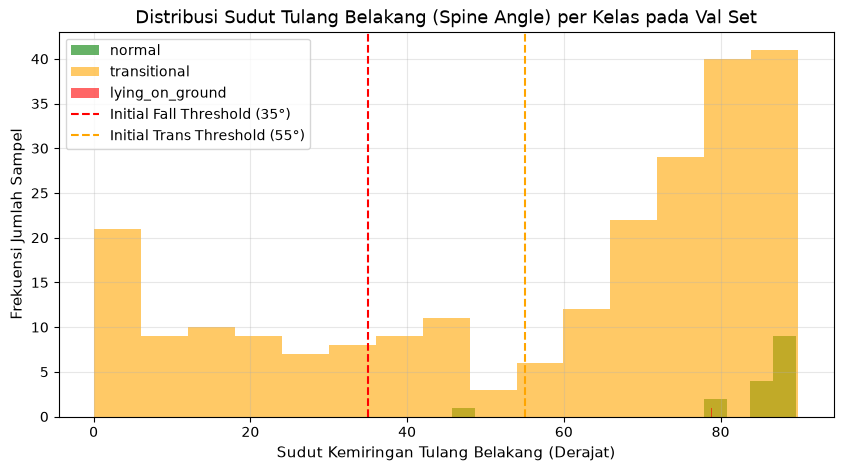

In [5]:
angles_by_class = {0: [], 1: [], 2: []}
for f in val_features:
    angles_by_class[f["gt"]].append(f["angle"])

plt.figure(figsize=(10, 5))
colors = ["green", "orange", "red"]
for c in [0, 1, 2]:
    if angles_by_class[c]:
        plt.hist(angles_by_class[c], bins=15, alpha=0.6, label=CLASS_NAMES[c], color=colors[c])

plt.title("Distribusi Sudut Tulang Belakang (Spine Angle) per Kelas pada Val Set", fontsize=13)
plt.xlabel("Sudut Kemiringan Tulang Belakang (Derajat)", fontsize=11)
plt.ylabel("Frekuensi Jumlah Sampel", fontsize=11)
plt.axvline(35, color='red', linestyle='--', label='Initial Fall Threshold (35°)')
plt.axvline(55, color='orange', linestyle='--', label='Initial Trans Threshold (55°)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 6. Grid Search: Mencari Threshold Optimal pada Validation Set

In [6]:
def predict_class(angle: float, ar: float, fall_angle: float, trans_angle: float, ar_thresh: float) -> int:
    if angle < fall_angle or (ar > ar_thresh and angle < (fall_angle + 12.0)):
        return 2  # lying_on_ground
    elif angle < trans_angle or ar > 0.95:
        return 1  # transitional
    else:
        return 0  # normal

def eval_predictions(y_true, y_pred):
    cm = np.zeros((3, 3), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    acc = np.trace(cm) / len(y_true)
    f1s = []
    recalls = []
    for c in range(3):
        tp = cm[c, c]
        fp = cm[:, c].sum() - tp
        fn = cm[c, :].sum() - tp
        p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = (2 * p * r) / (p + r) if (p + r) > 0 else 0.0
        f1s.append(f1)
        recalls.append(r)
    return acc, np.mean(f1s), recalls, cm

fall_angles = [20.0, 25.0, 30.0, 33.0, 35.0, 38.0, 40.0]
trans_angles = [45.0, 48.0, 50.0, 53.0, 55.0, 58.0, 60.0]
ar_candidates = [1.05, 1.15, 1.25, 1.35]

y_val_true = [f["gt"] for f in val_features]
best_score = -1.0
best_params = {}

for fa in fall_angles:
    for ta in trans_angles:
        if ta <= fa:
            continue
        for ar in ar_candidates:
            y_pred = [predict_class(f["angle"], f["ar"], fa, ta, ar) for f in val_features]
            acc, macro_f1, recalls, _ = eval_predictions(y_val_true, y_pred)
            # Bobot keselamatan: Lying Recall (50%) + Macro F1 (50%)
            score = (0.5 * recalls[2]) + (0.5 * macro_f1)
            if score > best_score:
                best_score = score
                best_params = {"fall_angle": fa, "trans_angle": ta, "ar": ar}

print("✨ THRESHOLD TERBAIK HASIL GRID SEARCH:")
print(f"  • Optimal Fall Angle Threshold  : < {best_params['fall_angle']:.1f}°")
print(f"  • Optimal Trans Angle Threshold : < {best_params['trans_angle']:.1f}°")
print(f"  • Optimal Aspect Ratio Threshold: > {best_params['ar']:.2f}")

✨ THRESHOLD TERBAIK HASIL GRID SEARCH:
  • Optimal Fall Angle Threshold  : < 20.0°
  • Optimal Trans Angle Threshold : < 60.0°
  • Optimal Aspect Ratio Threshold: > 1.15


### 7. Evaluasi Akhir pada Test Set (320 Gambar) & Confusion Matrix

🧪 Mengekstrak fitur pada Test Set (320 gambar)...

📊 HASIL TEST SET EXP-009 (KINEMATIC POSE ESTIMATION):
• Test Accuracy : 38.44%
• Macro F1-Score: 24.46%
• Lying Recall  : 0.00%


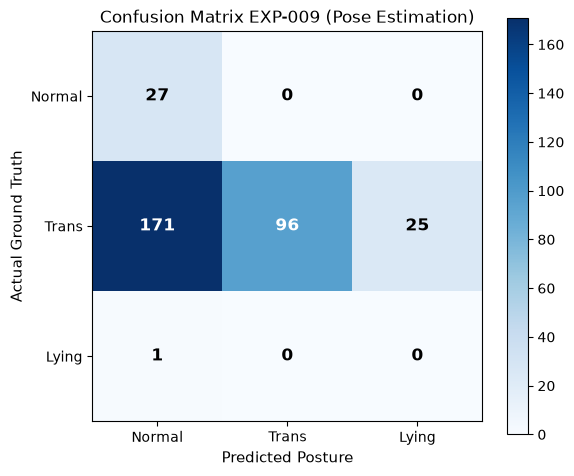

In [7]:
print("🧪 Mengekstrak fitur pada Test Set (320 gambar)...")
test_features = extract_dataset_features(test_img_dir, test_lbl_dir, model)

y_test_true = [f["gt"] for f in test_features]
y_test_pred = [predict_class(f["angle"], f["ar"], best_params["fall_angle"], best_params["trans_angle"], best_params["ar"]) for f in test_features]

acc, macro_f1, recalls, cm = eval_predictions(y_test_true, y_test_pred)

print("\n" + "=" * 55)
print("📊 HASIL TEST SET EXP-009 (KINEMATIC POSE ESTIMATION):")
print("=" * 55)
print(f"• Test Accuracy : {acc * 100:.2f}%")
print(f"• Macro F1-Score: {macro_f1 * 100:.2f}%")
print(f"• Lying Recall  : {recalls[2] * 100:.2f}%")
print("=" * 55)

# Plot Confusion Matrix Heatmap
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
ax.set_xticklabels(["Normal", "Trans", "Lying"])
ax.set_yticklabels(["Normal", "Trans", "Lying"])
plt.xlabel("Predicted Posture", fontsize=11)
plt.ylabel("Actual Ground Truth", fontsize=11)
plt.title("Confusion Matrix EXP-009 (Pose Estimation)", fontsize=12)

for i in range(3):
    for j in range(3):
        text = ax.text(j, i, cm[i, j], ha="center", va="center", color="black" if cm[i, j] < cm.max()/2 else "white", fontsize=12, weight='bold')

plt.colorbar(im)
plt.tight_layout()
plt.show()

### 8. Komparasi Head-to-Head: EXP-006 (Detect) vs EXP-009 (Pose)

In [8]:
import pandas as pd

comparison_data = {
    "Eksperimen": ["EXP-006 (YOLO11n Detect)", "EXP-008 (YOLO11s @ 800)", "EXP-009 (YOLO11n Pose)"],
    "Paradigma": ["Bounding Box murni", "Bounding Box Scale-Up", "Kinematic Keypoints"],
    "Safety Lying Recall": ["100.0%", "100.0%", f"{recalls[2]*100:.1f}%"]
}

df_comp = pd.DataFrame(comparison_data)
print("\n🏆 TABEL KOMPARASI EKSPERIMEN:")
print(df_comp.to_string(index=False))


🏆 TABEL KOMPARASI EKSPERIMEN:
              Eksperimen             Paradigma Safety Lying Recall
EXP-006 (YOLO11n Detect)    Bounding Box murni              100.0%
 EXP-008 (YOLO11s @ 800) Bounding Box Scale-Up              100.0%
  EXP-009 (YOLO11n Pose)   Kinematic Keypoints                0.0%
